# Immersed-boundary diffusion around two touching particles

This example demonstrates the **general boundary/interface conditions** of the `pymrm`
immersed boundary method (IBM): `construct_ibm_normal_derivative`,
`construct_ibm_boundary_values` and `apply_ibm_interface`.  Two solid particles of
radius $R$ touch on the centreline of a unit square filled with fluid.  Steady
diffusion is driven by domain boundary conditions $c=1$ (left) and $c=0$ (right), with
no-flux top and bottom walls.

We solve the same geometry twice:

1. **Impermeable particles** -- in the fluid a *homogeneous Neumann* condition
   $\partial c/\partial n = 0$ is imposed at the particle surface, while the inside of
   the particles is held at a *Dirichlet* value.  The two sides are completely
   decoupled: the immersed wall is a no-flux obstacle for the fluid.
2. **Conjugate interface** -- the particles have their own diffusion coefficient
   $D_\mathrm{in} \ne D_\mathrm{out}$ and the two regions are coupled through flux and
   value continuity at the surface.

The machinery has three layers:

* `construct_ibm_particles` -- from the analytic `Circle` particles it finds the wall
  crossings and builds the directional ghost-cell data, with exact wall positions and
  outward normals (`info.normals`); the standard `IBM` object it returns feeds every
  step below;
* `construct_ibm_normal_derivative` -- builds, on each side of every crossing, a
  one-sided formula for the **outward normal derivative** at the wall,
  $q_\mathrm{side} \approx \alpha_\mathrm{side}\, c_\Gamma^\mathrm{side} + \sum_j \gamma_j c_j$,
  from generalized finite differences on same-side cells;
* `construct_ibm_boundary_values` / `apply_ibm_interface` -- eliminate the unknown wall
  values $c_\Gamma$ from the given boundary/interface equations and fold the result
  into the operator matrix.

Sign convention: the derivatives are *outward per side*, i.e. $q_\mathrm{out}$ points
out of the fluid (into the solid) and $q_\mathrm{in}$ points out of the solid, exactly
as in `construct_interface_matrices` for grid-aligned multi-region models.

In [1]:
import numpy as np
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from pymrm import (
    construct_grad, construct_div, construct_coefficient_matrix,
    apply_ibm, apply_ibm_vector, construct_ibm_particles, Circle as Disk,
    construct_ibm_normal_derivative, construct_ibm_normal_derivative_ops,
    apply_ibm_interface, construct_ibm_boundary_values,
)

# --- Geometry and grid ---
L = 1.0                              # domain size
N = 100                              # cells per direction
R = 0.2                              # particle radius
centers = [(0.3, 0.5), (0.7, 0.5)]   # the particles touch at (0.5, 0.5)

shape = (N, N)
n = N * N
x_f = [np.linspace(0.0, L, N + 1), np.linspace(0.0, L, N + 1)]
x_c = [0.5 * (xf[:-1] + xf[1:]) for xf in x_f]
X, Y = np.meshgrid(x_c[0], x_c[1], indexing='ij')

## Analytic particles, IBM data and normal-derivative operators

The two disks are `Circle` particles; `construct_ibm_particles` locates the wall
crossings, computing each cut-face wall position and outward normal **exactly** from
the owning circle.  With `contact='merge'` the touching disks act as one connected
solid (as a union level set would), so no artificial crossing is created between them.
`construct_ibm_normal_derivative` then builds the one-sided normal-derivative operators
used by both parts of this notebook; we pass `length_scale=R` so stencils never reach
farther than a fraction of the particle radius, and `normals=info.normals` so they use
the exact surface normals.

The contact point is a geometric stress test: the fluid gap between the particles
pinches to zero width and the solid is connected through the contact.  Because the
normals come from the analytic circles they stay exact right at the contact; the GFD
stencil still lowers its polynomial degree there where too few well-placed same-side
cells are available (the `degree_*` diagnostics below), and its flood-fill
connectivity filter keeps stencils from leaking through the pinch to the other side.

wall crossings         : 304
out-side degrees used  : p=2: 296, p=1: 8   (unresolved: 0)
 in-side degrees used  : p=2: 304   (unresolved: 0)


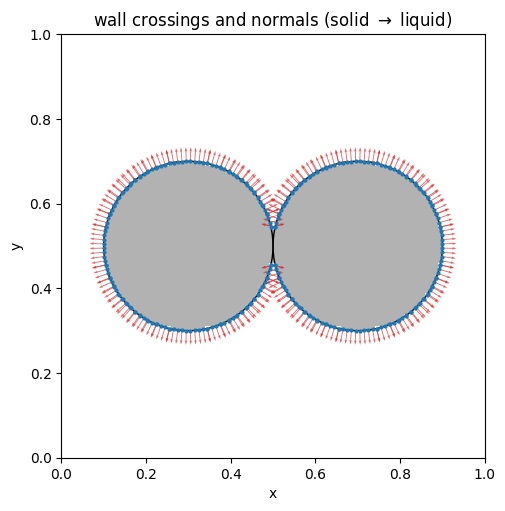

In [2]:
# The disks are described analytically.  contact='merge' keeps the union
# behaviour (touching disks act as one connected solid, as with the SDF),
# while the wall positions and normals are now exact per particle.
particles = [Disk((cx, cy), R) for cx, cy in centers]
ibm, info = construct_ibm_particles(particles, x_c, contact='merge')
sdf = info.pseudo_sdf                        # sign-correct union field
fluid = (sdf >= 0).ravel()                  # phase mask (True = liquid)
solid2d = (sdf < 0)

recon = construct_ibm_normal_derivative(ibm, sdf, x_c, length_scale=R,
                                     normals=info.normals)

print(f'wall crossings         : {ibm.n_crossings}')
for side in ('out', 'in'):
    deg = getattr(recon, f'degree_{side}')
    unres = getattr(recon, f'unresolved_{side}')
    counts = ', '.join(f'p={p}: {np.sum(deg == p)}' for p in np.unique(deg)[::-1])
    print(f'{side:>3}-side degrees used  : {counts}   (unresolved: {unres.sum()})')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pcolormesh(x_f[0], x_f[1], solid2d.T, cmap='Greys', alpha=0.3, shading='flat')
ax.quiver(ibm.coords[:, 0], ibm.coords[:, 1],
          recon.normals[:, 0], recon.normals[:, 1],
          angles='xy', scale=30, width=0.002, color='tab:red', alpha=0.7)
ax.scatter(ibm.coords[:, 0], ibm.coords[:, 1], s=4, c='tab:blue', zorder=3)
for cx, cy in centers:
    ax.add_patch(Circle((cx, cy), R, fill=False, color='k', lw=1.0))
ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(r'wall crossings and normals (solid $\to$ liquid)')
plt.show()

## Bare Laplacian with the domain boundary conditions

We assemble the plain Laplacian $\mathsf{Lap} = \mathrm{div}(\mathrm{grad})$ **once**,
without any diffusion coefficient, including the domain boundary conditions (Dirichlet
$c=1$ left, $c=0$ right, no-flux top/bottom).  The diffusion coefficient is applied
afterwards as a **cell-centred** diagonal factor (next section), which is exactly the
$-D\,\mathrm{div}(\mathrm{grad})$ form we want.  The usual `pymrm` sign convention
applies: the boundary contribution $g$ is *added*, so the bare-Laplacian equation reads
$\mathsf{Lap}\, c + g_\mathrm{lap} = \dots$.

In [3]:
bc_x = ({'a': 0, 'b': 1, 'd': 1.0}, {'a': 0, 'b': 1, 'd': 0.0})   # c=1 left, c=0 right
bc_y = ({'a': 1, 'b': 0, 'd': 0.0}, {'a': 1, 'b': 0, 'd': 0.0})   # no-flux top/bottom


def laplacian_operator():
    """Lap = div(grad) with the domain BCs; convention: Lap @ c + g_lap = source/D."""
    Lap = None
    g_lap = np.zeros(n)
    for axis, bc in enumerate((bc_x, bc_y)):
        grad, grad_bc = construct_grad(shape, x_f[axis], x_c[axis], bc=bc, axis=axis)
        div = construct_div(shape, x_f[axis], axis=axis)
        term = (div @ grad).tocsr()
        Lap = term if Lap is None else Lap + term
        g_lap += (div @ grad_bc).toarray().ravel()
    return Lap, g_lap


Lap, g_lap = laplacian_operator()

### Boundary molar flows (for the overall mole balance)

To check the overall mole balance we need the molar flow crossing the left and right
outer walls.  The $x$-derivative at the vertical grid faces is
$\partial c/\partial x = \mathsf{grad}_x\, c + g_{\mathrm{grad},x}$ (the same finite-volume
gradient used in the operator), and the molar flux in the $+x$ direction is
$-D\,\partial c/\partial x$.  Integrating that flux over a boundary column of faces
gives the molar flow (per unit depth) through that wall; both outer walls lie in the
fluid, so the fluid coefficient applies there.  A positive `flow_left` **enters** the
domain and a positive `flow_right` **leaves** it.  In steady state with no volumetric
sources the two must be equal to solver precision -- the discrete finite-volume fluxes
telescope, so whatever enters at the left has to leave at the right.

In [4]:
grad_x, grad_bc_x = construct_grad(shape, x_f[0], x_c[0], bc=bc_x, axis=0)
grad_bc_x = grad_bc_x.toarray().ravel()
dy = np.diff(x_f[1])


def boundary_molar_flows(c, D_liquid):
    """Molar flow (per unit depth) through the left and right outer boundaries."""
    dcdx = (grad_x @ c + grad_bc_x).reshape(N + 1, N)   # dc/dx at the x-faces
    flux_x = -D_liquid * dcdx                            # molar flux in +x
    flow_left = np.sum(flux_x[0, :] * dy)               # +x through x=0  (inflow)
    flow_right = np.sum(flux_x[N, :] * dy)              # +x through x=L  (outflow)
    return flow_left, flow_right

## Part 1: no-flux particles (Neumann outside, Dirichlet inside)

On the **fluid side** we impose the homogeneous Neumann condition

$$1 \cdot q_\mathrm{out} + 0 \cdot c_\Gamma^\mathrm{out} = 0
\qquad\Longleftrightarrow\qquad \left.\frac{\partial c}{\partial n}\right|_\Gamma = 0 ,$$

i.e. the wall equation dictionary `{'a': 1, 'b': 0, 'd': 0}` (any Robin condition
`a*q + b*c = d` works the same way).  `construct_ibm_boundary_values` eliminates the
unknown fluid-side wall value, returning it as a sparse function of the field,
$c_\Gamma^\mathrm{out} = \mathsf H c + h$.  This enters the system through the wall
source matrices `G_out`/`G_in` returned by `apply_ibm(..., return_bc='matrix')`.

The **solid side** is completely decoupled from the fluid: there we simply prescribe a
Dirichlet wall value $c_\Gamma^\mathrm{in} = c_\mathrm{solid}$, exactly as in the plain
Dirichlet IBM (a known value contributes `G_in @ values` to the source).  Since the
solid interior keeps a diffusion equation with this wall value as its only boundary
condition, it relaxes to the uniform value $c_\mathrm{solid}$ -- it is only there for
display; the fluid solution does not depend on it.

As with the Dirichlet IBM, any independently assembled right-hand-side contribution
(here the domain-boundary vector `g_bc`) must pass through `apply_ibm_vector` so it
receives the same row conditioning as the matrix.

In [5]:
D = 1.0          # diffusion coefficient of the liquid
c_solid = 0.5    # Dirichlet wall value seen from the inside

# -D div(grad); D is uniform here (the impermeable solid is decoupled)
L_mat = (-D * Lap).tocsr()
g_bc = -D * g_lap

# Ghost-cell folding; G_out / G_in route wall values into the cut-cell rows
A_ibm, G_out, G_in = apply_ibm(L_mat, ibm, return_bc='matrix')

# Liquid side: 1 * q_out + 0 * c_wall = 0  ->  homogeneous Neumann (no flux)
H, h = construct_ibm_boundary_values(ibm, recon,
                                     {'a': 1.0, 'b': 0.0, 'd': 0.0}, side='out')
A1 = (A_ibm + G_out @ H).tocsr()

# Solid side: known Dirichlet wall values
val_in = np.full(ibm.n_crossings, c_solid)
g1 = (apply_ibm_vector(g_bc, ibm)
      + np.asarray(G_out @ h).ravel()
      + np.asarray(G_in @ val_in).ravel())

c1 = spsolve(A1.tocsc(), -g1)          # steady state: A1 @ c + g1 = 0
c1_2d = c1.reshape(shape)

print(f'liquid min/max : {c1[fluid].min():.4f} / {c1[fluid].max():.4f}')
print(f'solid  min/max : {c1[~fluid].min():.4f} / {c1[~fluid].max():.4f}   '
      f'(should equal c_solid = {c_solid})')

liquid min/max : 0.0011 / 0.9989
solid  min/max : 0.5000 / 0.5000   (should equal c_solid = 0.5)


With impermeable particles all flux has to bend around the solid: iso-concentration
lines meet the surface at right angles (zero normal derivative).  The profile through
the particle centreline shows the decoupling -- the solid sits at $c_\mathrm{solid}$,
independent of the neighbouring fluid values.

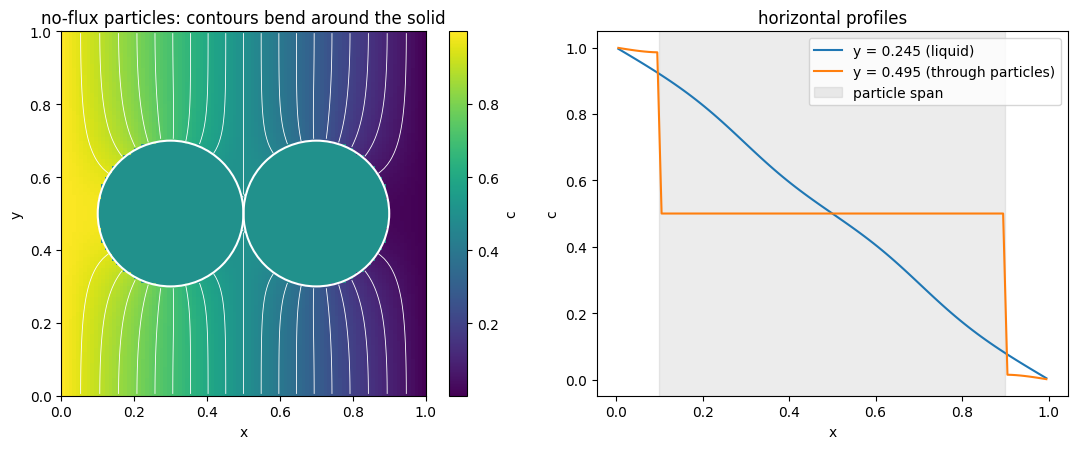

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))

m = axs[0].pcolormesh(x_f[0], x_f[1], c1_2d.T, shading='flat', cmap='viridis')
axs[0].contour(X, Y, np.ma.masked_array(c1_2d, mask=solid2d),
               levels=np.linspace(0.05, 0.95, 19), colors='w', linewidths=0.6)
for cx, cy in centers:
    axs[0].add_patch(Circle((cx, cy), R, fill=False, color='w', lw=1.5))
axs[0].set_aspect('equal')
axs[0].set_xlabel('x'); axs[0].set_ylabel('y')
axs[0].set_title('no-flux particles: contours bend around the solid')
fig.colorbar(m, ax=axs[0], label='c')

j_side = np.argmin(np.abs(x_c[1] - 0.25))
j_mid = np.argmin(np.abs(x_c[1] - 0.5))
axs[1].plot(x_c[0], c1_2d[:, j_side], label=f'y = {x_c[1][j_side]:.3f} (liquid)')
axs[1].plot(x_c[0], c1_2d[:, j_mid], label=f'y = {x_c[1][j_mid]:.3f} (through particles)')
axs[1].axvspan(centers[0][0] - R, centers[1][0] + R, color='grey', alpha=0.15,
               label='particle span')
axs[1].set_xlabel('x'); axs[1].set_ylabel('c')
axs[1].set_title('horizontal profiles')
axs[1].legend()
plt.tight_layout()
plt.show()

**Overall mole balance.**  The fluid is source-free and the particle surfaces carry
no flux, so every mole entering at the left must leave at the right.  The empty channel
(no particles) would pass $D\,\Delta c\,H/W = D = 1$; the impermeable particles obstruct
the path and reduce the throughput below that reference.

In [7]:
flow_left, flow_right = boundary_molar_flows(c1, D)
print(f'left  boundary (inflow)  : {flow_left:.6f}')
print(f'right boundary (outflow) : {flow_right:.6f}')
print(f'relative imbalance       : {abs(flow_left - flow_right) / abs(flow_left):.2e}')
print(f'empty-channel reference  : {D:.6f}  '
      f'(throughput ratio {flow_left / D:.3f})')

left  boundary (inflow)  : 0.672428
right boundary (outflow) : 0.672428
relative imbalance       : 2.71e-13
empty-channel reference  : 1.000000  (throughput ratio 0.672)


## Part 2: conjugate interface with different diffusion coefficients

Now the particles participate in the transport with their own diffusivity
$D_\mathrm{in} \ne D_\mathrm{out}$, coupled to the fluid by the conjugate interface
conditions

$$D_\mathrm{out}\, q_\mathrm{out} + D_\mathrm{in}\, q_\mathrm{in} = 0
\qquad\text{(flux continuity)},\qquad
c_\Gamma^\mathrm{out} - c_\Gamma^\mathrm{in} = 0
\qquad\text{(value continuity)} .$$

(Remember $q_\mathrm{out}$ and $q_\mathrm{in}$ are both *outward* derivatives, so flux
continuity is a **sum**, not a difference.)  In dictionary form -- identical to the
`ic` format of `construct_interface_matrices` -- this is

```python
ic = ({'a': (D_out, D_in), 'b': (0.0, 0.0), 'd': 0.0},
      {'a': (0.0, 0.0), 'b': (1.0, -1.0), 'd': 0.0})
```

A partition coefficient ($c_\mathrm{out} = K\, c_\mathrm{in}$) or a contact resistance
would only change these coefficients.

### Keep the diffusion coefficient outside the Laplacian

Away from the interface each region has a *uniform* diffusion coefficient, so before
the interface conditions are applied the balances are simply

$$\text{fluid: } -D_\mathrm{out}\nabla^2 c = 0,
\qquad
\text{solid: } -D_\mathrm{in}\nabla^2 c = 0 ,$$

i.e. the diffusion coefficient sits **outside** the Laplacian.  We build this directly:
one bare Laplacian $\mathsf{Lap} = \mathrm{div}(\mathrm{grad})$ (already assembled above)
and a **cell-centred field** of diffusion coefficients, $D_\mathrm{out}$ in the fluid
and $D_\mathrm{in}$ in the solid.  `construct_coefficient_matrix` turns that field into a
diagonal matrix $\mathsf D$, and the operator is simply

$$\mathsf L = -\,\mathsf D\,\mathsf{Lap} .$$

Because $\mathsf D$ is diagonal it just scales each row (each cell equation) by the
diffusion coefficient at that cell centre.  We deliberately do *not* define $D$ on the
cell **faces** through a mixture rule (harmonic or arithmetic averaging of
$D_\mathrm{out}$ and $D_\mathrm{in}$): a face-averaged coefficient would impose its own
smeared, first-order coupling across the cut cells and interfere with the sharp
ghost-cell treatment.  All communication between the two regions must come exclusively
from the interface conditions, which `apply_ibm_interface` folds into the cut-cell rows.

In [8]:
D_out, D_in = 1.0, 5.0     # liquid / particle diffusion coefficients

# Cell-centred diffusion-coefficient field: D_out in the liquid, D_in in the solid
D_field = np.where(solid2d, D_in, D_out)          # shape (N, N)
D_mat = construct_coefficient_matrix(D_field, shape=shape)   # diagonal D matrix

# Operator -D div(grad): D outside the Laplacian, defined at cell centres
L2 = (-D_mat @ Lap).tocsr()
g2 = -(D_mat @ g_lap)

# Conjugate interface conditions: flux continuity + value continuity
ic = ({'a': (D_out, D_in), 'b': (0.0, 0.0), 'd': 0.0},
      {'a': (0.0, 0.0), 'b': (1.0, -1.0), 'd': 0.0})

A2, g_ic, (H_out, h_out, H_in, h_in) = apply_ibm_interface(
    L2, ibm, recon, ic, return_values=True)

c2 = spsolve(A2.tocsc(), apply_ibm_vector(-g2, ibm) - g_ic)
c2_2d = c2.reshape(shape)

### Interface values and fluxes

With `return_values=True` we also get the elimination operators
$c_\Gamma^\mathrm{side} = \mathsf H_\mathrm{side}\, c + h_\mathrm{side}$, useful for
post-processing wall concentrations and, combined with
`construct_ibm_normal_derivative_ops`, wall fluxes.  Since the elimination enforces the two
interface equations exactly, the recovered values satisfy them to machine precision --
a consistency check of the assembly (the *accuracy* of the solution is governed by the
reconstruction order, second order here).

In [9]:
cg_out = H_out @ c2 + h_out
cg_in = H_in @ c2 + h_in

alpha_o, N_o, alpha_i, N_i = construct_ibm_normal_derivative_ops(ibm, recon)
q_out = alpha_o * cg_out + N_o @ c2
q_in = alpha_i * cg_in + N_i @ c2

print(f'max |c_out - c_in|            : {np.abs(cg_out - cg_in).max():.2e}')
print(f'max |D_out q_out + D_in q_in| : {np.abs(D_out * q_out + D_in * q_in).max():.2e}')

max |c_out - c_in|            : 0.00e+00
max |D_out q_out + D_in q_in| : 4.55e-13


Because the particles conduct better than the fluid ($D_\mathrm{in} = 5 D_\mathrm{out}$),
iso-concentration lines are now *attracted into* the solid and refract at the surface.
The centreline profile is continuous across the interfaces (value continuity) but shows
a kink: flux continuity forces the slope inside the particles to be about
$D_\mathrm{out}/D_\mathrm{in}$ times the outside slope.

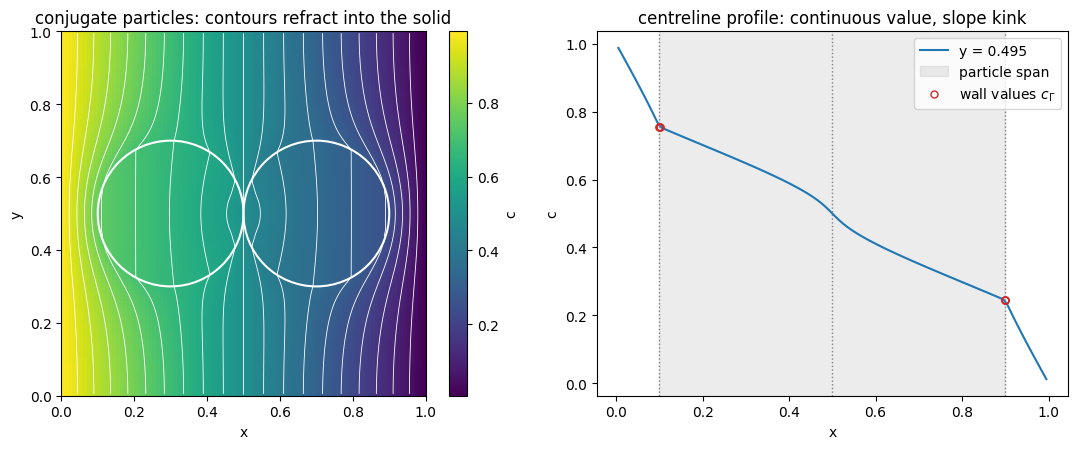

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))

m = axs[0].pcolormesh(x_f[0], x_f[1], c2_2d.T, shading='flat', cmap='viridis')
axs[0].contour(X, Y, c2_2d, levels=np.linspace(0.05, 0.95, 19),
               colors='w', linewidths=0.6)
for cx, cy in centers:
    axs[0].add_patch(Circle((cx, cy), R, fill=False, color='w', lw=1.5))
axs[0].set_aspect('equal')
axs[0].set_xlabel('x'); axs[0].set_ylabel('y')
axs[0].set_title('conjugate particles: contours refract into the solid')
fig.colorbar(m, ax=axs[0], label='c')

j_mid = np.argmin(np.abs(x_c[1] - 0.5))
axs[1].plot(x_c[0], c2_2d[:, j_mid], label=f'y = {x_c[1][j_mid]:.3f}')
for xi in (centers[0][0] - R, 0.5, centers[1][0] + R):
    axs[1].axvline(xi, color='grey', ls=':', lw=1)
axs[1].axvspan(centers[0][0] - R, centers[1][0] + R, color='grey', alpha=0.15,
               label='particle span')
# wall concentrations of the crossings closest to the centreline
sel = np.abs(ibm.coords[:, 1] - 0.5) < 0.02
axs[1].plot(ibm.coords[sel, 0], cg_out[sel], 'o', ms=5, mfc='none',
            color='tab:red', label=r'wall values $c_\Gamma$')
axs[1].set_xlabel('x'); axs[1].set_ylabel('c')
axs[1].set_title('centreline profile: continuous value, slope kink')
axs[1].legend()
plt.tight_layout()
plt.show()

**Overall mole balance.**  The interface conditions enforce flux continuity, so no
moles accumulate at the particle surfaces; with a source-free interior the inflow again
equals the outflow.  Now the better-conducting particles ($D_\mathrm{in} = 5\,
D_\mathrm{out}$) form high-conductance bridges across the channel, so the throughput
*exceeds* the empty-channel reference $D_\mathrm{out} = 1$.

In [11]:
flow_left, flow_right = boundary_molar_flows(c2, D_out)
print(f'left  boundary (inflow)  : {flow_left:.6f}')
print(f'right boundary (outflow) : {flow_right:.6f}')
print(f'relative imbalance       : {abs(flow_left - flow_right) / abs(flow_left):.2e}')
print(f'empty-channel reference  : {D_out:.6f}  '
      f'(throughput ratio {flow_left / D_out:.3f})')

left  boundary (inflow)  : 1.553690
right boundary (outflow) : 1.553690
relative imbalance       : 2.95e-13
empty-channel reference  : 1.000000  (throughput ratio 1.554)


## Summary

* `construct_ibm_normal_derivative` provides one-sided normal-derivative formulas at every
  wall crossing; everything else in this notebook consumed them.
* A **single-side wall condition** (Neumann/Robin in the fluid, unmodelled or pinned
  solid) uses `construct_ibm_boundary_values` together with the `G_out`/`G_in` source
  matrices of `apply_ibm(..., return_bc='matrix')`.
* **Two-side interface conditions** (conjugate transfer, partition coefficients,
  contact resistance) use `apply_ibm_interface` with the same two-equation `ic`
  dictionaries as grid-aligned `construct_interface_matrices`.
* For piecewise-constant diffusivities, build one bare Laplacian and a cell-centred
  diffusion-coefficient field, then form $-\mathsf D\,\mathrm{div}(\mathrm{grad})$ with a
  diagonal $\mathsf D$ from `construct_coefficient_matrix` -- keeping $D$ outside the
  Laplacian, never a face-averaged $D$ -- so that the interface physics comes only from
  the imposed interface conditions.
* The overall mole balance closes to solver precision in both cases (left inflow = right
  outflow): impermeable particles reduce the throughput below the empty-channel value,
  while better-conducting particles raise it above.